# 📧 SMS Spam Classifier

Classify SMS messages as **ham** (normal message) or **spam** (ad / company message).

`predict_message(pred_text)` must return `[probability_of_spam, "ham" or "spam"]`.

Architecture: Embedding → GlobalAveragePooling1D → Dense(1, sigmoid). See project README for why pooling was chosen over LSTM for this dataset.

## 1. *Libraries importation*

In [2]:
pip install tensorflow tensorflow_datasets

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached tensorflow_datasets-4.9.10-py3-none-any.whl.metadata (11 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)Note: you may need to restart the kernel to use updated packages.

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wra


[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
import tensorflow as tf
import pandas as pd
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
print(tf.__version__)


2.21.0


## 2. *Get data files*

In [42]:
headers = {"User-Agent": "Mozilla/5.0"}

for url, filename in [
    ("https://cdn.freecodecamp.org/project-data/sms/train-data.tsv", "train-data.tsv"),
    ("https://cdn.freecodecamp.org/project-data/sms/valid-data.tsv", "valid-data.tsv"),
]:
    # Download the file from `url` and save it locally under `filename`
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req) as response, open(filename, "wb") as out_file:
        out_file.write(response.read())

train_file_path = "train-data.tsv"
test_file_path = "valid-data.tsv"

## 3. *Load data*

In [43]:
# Load the data(train and test) into pandas dataframe

train_df = pd.read_csv("train-data.tsv", sep="\t", header=None, names=["Label", "Message"])

test_df = pd.read_csv("valid-data.tsv", sep="\t", header=None, names=["Label", "Message"])

In [44]:
train_df.head()

,Label,Message
0,ham,ahhhh...just woken up!had a bad dream about u ...
1,ham,you can never do nothing
2,ham,"now u sound like manky scouse boy steve,like! ..."
3,ham,mum say we wan to go then go... then she can s...
4,ham,never y lei... i v lazy... got wat? dat day ü ...


In [45]:
train_df.shape

(4179, 2)

In [46]:
train_df["Label"].value_counts()

Label
ham     3619
spam     560
Name: count, dtype: int64

In [47]:
test_df.head()

,Label,Message
0,ham,i am in hospital da. . i will return home in e...
1,ham,"not much, just some textin'. how bout you?"
2,ham,i probably won't eat at all today. i think i'm...
3,ham,don‘t give a flying monkeys wot they think and...
4,ham,who are you seeing?


In [48]:
test_df.shape

(1392, 2)

In [49]:
test_df["Label"].value_counts()

Label
ham     1205
spam     187
Name: count, dtype: int64

# 4. *Data Visualization*

C:\Users\Soufiane Zekaoui\AppData\Local\Temp\ipykernel_1224\1748378476.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="Label", palette="viridis")


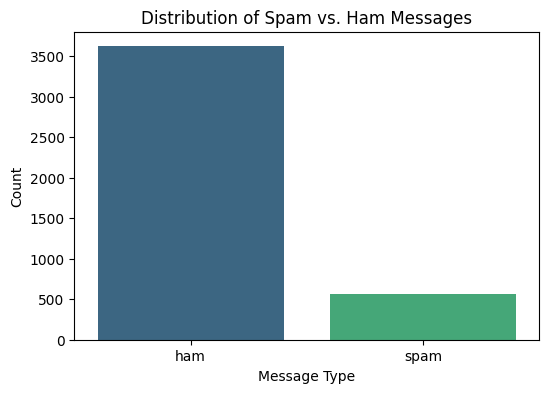

In [51]:
# Visualize the distribution of spam vs. ham
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="Label", palette="viridis")
plt.title("Distribution of Spam vs. Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

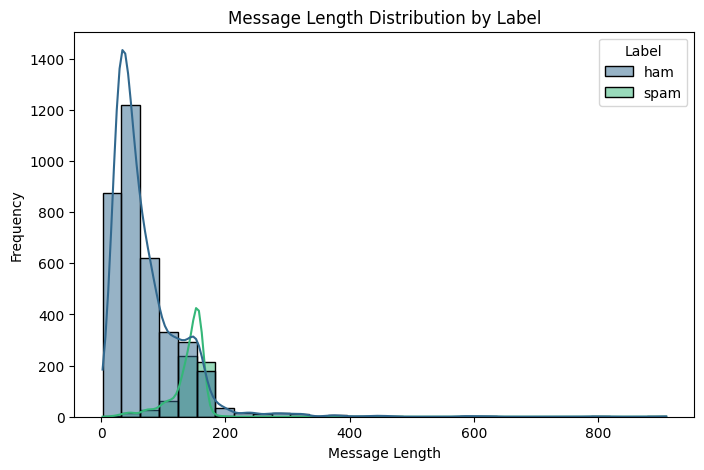

In [52]:
# Visualize the distribution of message lengths
train_df["Message_Length"] = train_df["Message"].apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(data=train_df, x="Message_Length", hue="Label", kde=True, palette="viridis", bins=30)
plt.title("Message Length Distribution by Label")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

## 5. *Preprocess*

In [123]:
# Prepare labels as numeric numpy arrays
train_labels = train_df["Label"].map({"ham": 0, "spam": 1}).astype("int32").to_numpy()
test_labels = test_df["Label"].map({"ham": 0, "spam": 1}).astype("int32").to_numpy()

# Prepare messages as numpy string arrays
train_messages = train_df["Message"].astype(str).to_numpy()
test_messages = test_df["Message"].astype(str).to_numpy()

In [124]:
# Calculate the maximum sequence length
train_df["Message_Length"] = train_df["Message"].apply(lambda x: len(x.split()))
max_length = train_df["Message_Length"].max()
max_tokens = 10000
print(f"Maximum sequence length: {max_length}")

Maximum sequence length: 171


In [125]:
# Create a TextVectorization layer
vectorizer = tf.keras.layers.TextVectorization(max_tokens= max_tokens, output_sequence_length=171)

# Adapt the vectorizer to the training data
vectorizer.adapt(train_messages)

## 6. *Build model*

In [126]:
model = tf.keras.Sequential([
    vectorizer,
    tf.keras.layers.Embedding(input_dim=max_tokens, output_dim=16),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),  # optional hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## 7. *Train*

In [127]:
class_weights_array = compute_class_weight(class_weight="balanced", classes=np.unique(train_labels), y=train_labels)

class_weight = {i: w for i, w in enumerate(class_weights_array)}
print(class_weight) # e.G {0: 0.5, 1: 2.0} for example

{0: np.float64(0.5773694390715667), 1: np.float64(3.73125)}


In [128]:
monitor = EarlyStopping(monitor='val_acc', min_delta=1e-4, patience=25, verbose=1, mode='max', restore_best_weights=True)

history = model.fit(
    train_messages, train_labels, validation_data=(test_messages, test_labels),
    class_weight=class_weight, callbacks=[monitor], epochs=300, verbose=2
)

Epoch 1/300
131/131 - 6s - 43ms/step - accuracy: 0.6387 - loss: 0.6931 - val_accuracy: 0.8657 - val_loss: 0.6702
Epoch 2/300


c:\Users\Soufiane Zekaoui\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\callbacks\early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


131/131 - 1s - 9ms/step - accuracy: 0.7552 - loss: 0.6861 - val_accuracy: 0.8657 - val_loss: 0.6189
Epoch 3/300
131/131 - 1s - 10ms/step - accuracy: 0.7808 - loss: 0.6706 - val_accuracy: 0.9684 - val_loss: 0.6489
Epoch 4/300
131/131 - 2s - 19ms/step - accuracy: 0.7602 - loss: 0.6240 - val_accuracy: 0.9691 - val_loss: 0.5625
Epoch 5/300
131/131 - 1s - 8ms/step - accuracy: 0.8993 - loss: 0.5012 - val_accuracy: 0.9684 - val_loss: 0.3558
Epoch 6/300
131/131 - 1s - 9ms/step - accuracy: 0.9335 - loss: 0.3627 - val_accuracy: 0.9698 - val_loss: 0.2406
Epoch 7/300
131/131 - 1s - 9ms/step - accuracy: 0.9797 - loss: 0.2453 - val_accuracy: 0.9670 - val_loss: 0.2436
Epoch 8/300
131/131 - 1s - 10ms/step - accuracy: 0.9739 - loss: 0.1949 - val_accuracy: 0.9691 - val_loss: 0.1559
Epoch 9/300
131/131 - 2s - 18ms/step - accuracy: 0.9739 - loss: 0.1717 - val_accuracy: 0.9088 - val_loss: 0.3130
Epoch 10/300
131/131 - 1s - 10ms/step - accuracy: 0.9777 - loss: 0.1391 - val_accuracy: 0.9698 - val_loss: 0.160

In [131]:
# Extract accuracy and loss from the history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_acc) + 1)

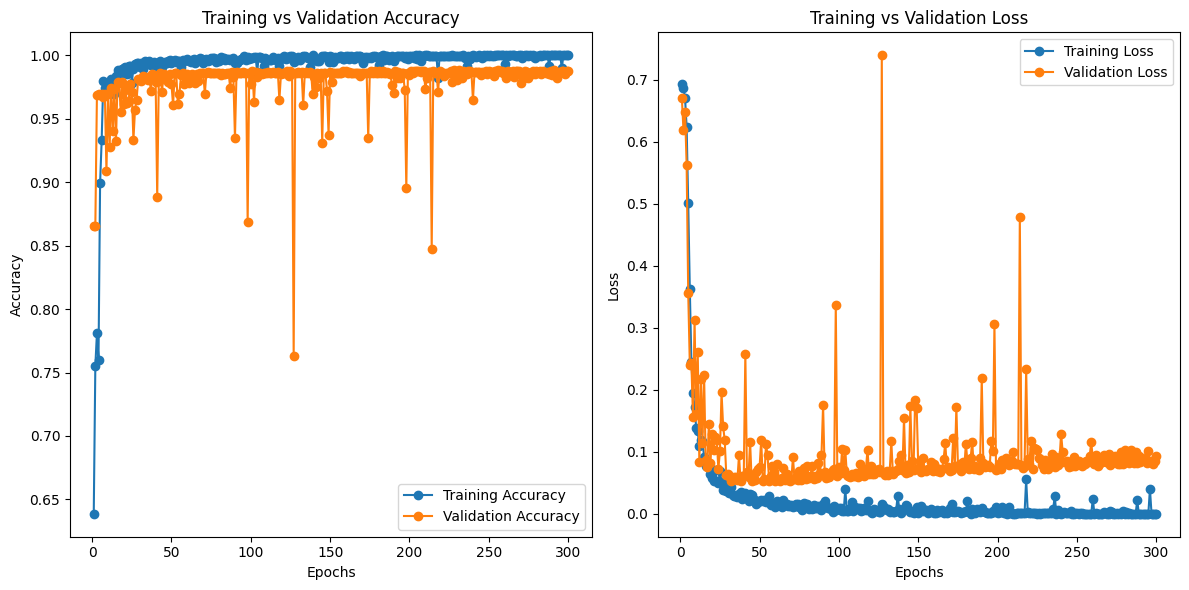

In [132]:
# Plot training vs validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training vs validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

## 8. *Predict function*

In [134]:
def predict_message(pred_text):
    # Convert to numpy array
    input_data = np.array([pred_text], dtype=object)

    prediction_prob = model.predict(input_data)[0][0]

    # Determine the label based on the probability
    label = "spam" if prediction_prob > 0.5 else "ham"

    # Return the prediction as a list [probability, label]
    prediction = [prediction_prob, label]
    return prediction

pred_text = "sale today! to stop texts call 98912460324"

prediction = predict_message(pred_text)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[np.float32(0.9930776), 'spam']


## 9. *Final test cell*

In [137]:
# Run this cell to test your function and model. Do not modify contents.
def test_predictions():
  test_messages = ["how are you doing today",
                   "sale today! to stop texts call 98912460324",
                   "i dont want to go. can we try it a different day? available sat",
                   "our new mobile video service is live. just install on your phone to start watching.",
                   "you have won £1000 cash! call to claim your prize.",
                   "i'll bring it tomorrow. don't forget the milk.",
                   "wow, is your arm alright. that happened to me one time too"
                  ]

  test_answers = ["ham", "spam", "ham", "spam", "spam", "ham", "ham"]
  passed = True

  for msg, ans in zip(test_messages, test_answers):
    prediction = predict_message(msg)
    if prediction[1] != ans:
      passed = False

  if passed:
    print("You passed the challenge. Great job!")
  else:
    print("You haven't passed yet. Keep trying.")

test_predictions()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
You passed the challenge. Great job!
